## **Logistic Regression: Gradient Descent Optimization**

### **Topic Roadmap**

**1. Dataset Generation**

**2. Scikit-Learn Baseline Model**

**3. Custom Gradient Descent Implementation**

**4. Decision Boundary Comparison**

### **1. Dataset Generation**

Generate a linearly separable binary classification dataset to visualize the optimization process.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")

# Generate binary classification dataset with clear separation
X, y = make_classification(
    n_samples=100, 
    n_features=2, 
    n_informative=1,
    n_redundant=0,
    n_classes=2, 
    n_clusters_per_class=1, 
    random_state=41,
    hypercube=False,
    class_sep=20
)

### **2. Scikit-Learn Baseline Model**

Train a standard Logistic Regression model. To ensure a fair comparison with our custom gradient descent (which lacks a regularization term), we set `penalty=None`.

In [22]:
# Train baseline model using the 'sag' solver without regularization
log_reg = LogisticRegression(penalty=None, solver='sag')
log_reg.fit(X, y)

# Calculate slope (m) and intercept (b) for the decision boundary: x2 = m*x1 + b
m_sklearn = -(log_reg.coef_[0][0] / log_reg.coef_[0][1])
b_sklearn = -(log_reg.intercept_[0] / log_reg.coef_[0][1])

x_bounds = np.linspace(-3, 3, 100)
y_bounds_sklearn = m_sklearn * x_bounds + b_sklearn

C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ART\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### **3. Custom Gradient Descent Implementation**

Implement the gradient descent algorithm using vectorized operations. The weight update rule is derived from the gradient of the log-loss function:

$$W = W + \alpha \frac{1}{N} X^T (Y - \hat{Y})$$

Where $\alpha$ is the learning rate, $N$ is the number of samples, $X$ is the feature matrix, and $\hat{Y}$ is the predicted probability.

In [23]:
def sigmoid(z):
    """Applies the sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def gradient_descent(X_data, y_data, learning_rate=0.5, epochs=5000):
    """
    Optimizes weights for Logistic Regression using batch gradient descent.
    """
    # Add an intercept column of 1s to the feature matrix
    X_with_bias = np.insert(X_data, 0, 1, axis=1)
    weights = np.ones(X_with_bias.shape[1])
    n_samples = X_with_bias.shape[0]
    
    for _ in range(epochs):
        # Calculate predictions
        y_hat = sigmoid(np.dot(X_with_bias, weights))
        
        # Vectorized weight update step
        gradient = np.dot((y_data - y_hat), X_with_bias) / n_samples
        weights = weights + learning_rate * gradient
        
    # Return coefficients and intercept separately
    return weights[1:], weights[0]

In [24]:
coef_gd, intercept_gd = gradient_descent(X, y)

# Calculate slope and intercept for the custom GD decision boundary
m_gd = -(coef_gd[0] / coef_gd[1])
b_gd = -(intercept_gd / coef_gd[1])

y_bounds_gd = m_gd * x_bounds + b_gd

### **4. Decision Boundary Comparison**

Visualize the dataset and overlay both decision boundaries to verify that the custom implementation converges to the same optimal parameters as the Scikit-Learn model.

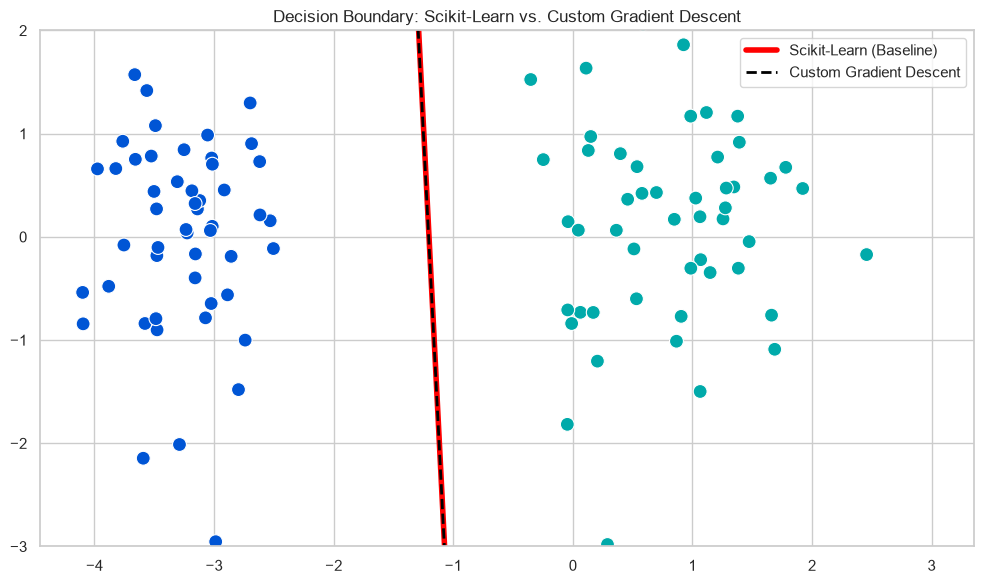

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='winter', s=100, legend=False)

# Plot both boundaries
plt.plot(x_bounds, y_bounds_sklearn, color='red', linewidth=4, label='Scikit-Learn (Baseline)')
plt.plot(x_bounds, y_bounds_gd, color='black', linewidth=2, linestyle='--', label='Custom Gradient Descent')

plt.ylim(-3, 2)
plt.title('Decision Boundary: Scikit-Learn vs. Custom Gradient Descent')
plt.legend()
plt.tight_layout()
plt.show()

### **Key Revision Notes**

- **Batch Gradient Descent:** Unlike the Perceptron trick that updates weights point-by-point, this implementation calculates the error across the entire dataset (`np.dot((y - y_hat), X)`) before applying a single, averaged weight update per epoch.
- **Loss Function Gradient:** The update rule dynamically scales the learning step. As the predicted probability `y_hat` approaches the true label `y`, the gradient approaches zero, naturally slowing down updates to prevent overshooting the minimum.
- **Model Equivalence:** The overlapping lines in the final plot confirm that Logistic Regression is fundamentally a gradient descent optimization over the log-loss function. Removing Scikit-Learn's default L2 penalty aligns its mathematical objective perfectly with the custom implementation.